In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Setup complete")

Setup complete


## Step 1: Scaled Dot-Product Attention (NumPy)

Formula: Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V

We implement this from scratch to understand each step.

In [2]:
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (seq_len, d_k)
    K: (seq_len, d_k)
    V: (seq_len, d_v)
    Returns: output (seq_len, d_v), weights (seq_len, seq_len)
    """
    d_k = Q.shape[-1]
    # Step 1: similarity scores
    scores = Q @ K.T / np.sqrt(d_k)   # (seq_len, seq_len)
    # Step 2: optional mask (for decoder causal mask)
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    # Step 3: softmax
    weights = softmax(scores, axis=-1)  # (seq_len, seq_len)
    # Step 4: weighted sum of values
    output = weights @ V               # (seq_len, d_v)
    return output, weights

# Demo: 4-token sequence, d_k = d_v = 8
np.random.seed(0)
seq_len, d_k, d_v = 4, 8, 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

out, attn_weights = scaled_dot_product_attention(Q, K, V)
print("Output shape:", out.shape)           # (4, 8)
print("Weights shape:", attn_weights.shape) # (4, 4)
print("Row sums (should be 1):", attn_weights.sum(axis=1).round(6))

Output shape: (4, 8)
Weights shape: (4, 4)
Row sums (should be 1): [1. 1. 1. 1.]


## Step 2: Attention Weight Heatmap

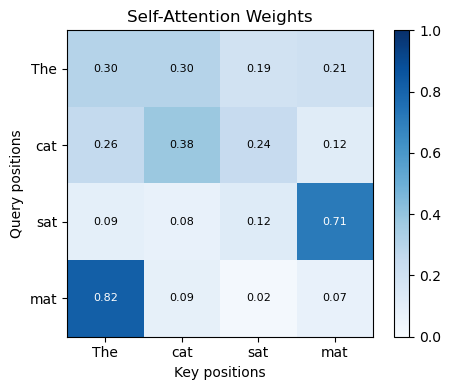

Attention heatmap saved


In [3]:
tokens = ["The", "cat", "sat", "mat"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn_weights, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)
ax.set_xlabel("Key positions")
ax.set_ylabel("Query positions")
ax.set_title("Self-Attention Weights")
plt.colorbar(im, ax=ax)

for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{attn_weights[i,j]:.2f}", ha="center", va="center",
                color="white" if attn_weights[i,j] > 0.5 else "black", fontsize=8)

plt.tight_layout()
plt.savefig("../docs/assets/07-attention-heatmap.png", dpi=96, bbox_inches="tight")
plt.show()
print("Attention heatmap saved")

## Step 3: Multi-Head Attention

Run h independent attention heads with different linear projections,
then concatenate and project back.

In [4]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads, seed=0):
        assert d_model % num_heads == 0
        rng = np.random.default_rng(seed)
        self.d_model = d_model
        self.h = num_heads
        self.d_k = d_model // num_heads
        # Weight matrices for Q, K, V projections per head
        self.WQ = [rng.standard_normal((d_model, self.d_k)) * 0.1 for _ in range(num_heads)]
        self.WK = [rng.standard_normal((d_model, self.d_k)) * 0.1 for _ in range(num_heads)]
        self.WV = [rng.standard_normal((d_model, self.d_k)) * 0.1 for _ in range(num_heads)]
        # Output projection
        self.WO = rng.standard_normal((d_model, d_model)) * 0.1

    def forward(self, X):
        """
        X: (seq_len, d_model)
        Returns: (seq_len, d_model)
        """
        head_outputs = []
        for i in range(self.h):
            Q = X @ self.WQ[i]  # (seq_len, d_k)
            K = X @ self.WK[i]
            V = X @ self.WV[i]
            out, _ = scaled_dot_product_attention(Q, K, V)
            head_outputs.append(out)  # (seq_len, d_k)
        # Concatenate all heads: (seq_len, d_model)
        concat = np.concatenate(head_outputs, axis=-1)
        return concat @ self.WO

# Demo: d_model=16, 4 heads, d_k=4 per head
np.random.seed(1)
seq_len, d_model, h = 6, 16, 4
X = np.random.randn(seq_len, d_model)

mha = MultiHeadAttention(d_model=d_model, num_heads=h, seed=42)
out_mha = mha.forward(X)
print("MHA input shape: ", X.shape)       # (6, 16)
print("MHA output shape:", out_mha.shape)  # (6, 16)

MHA input shape:  (6, 16)
MHA output shape: (6, 16)


## Step 4: Positional Encoding

PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

Different sine/cosine frequencies give each position a unique "fingerprint".

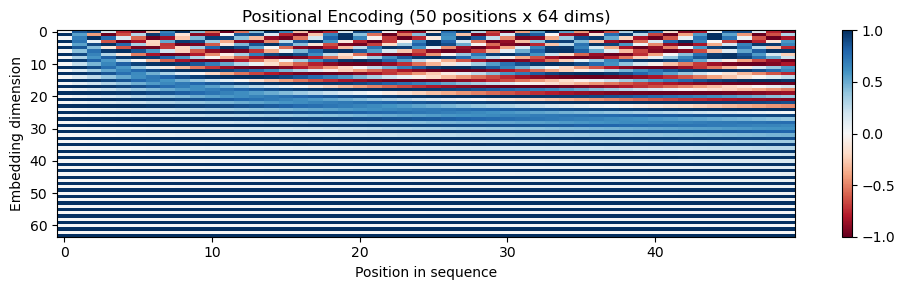

PE shape: (50, 64)
First 3 positions, first 6 dims:
[[ 0.     1.     0.     1.     0.     1.   ]
 [ 0.841  0.54   0.682  0.732  0.533  0.846]
 [ 0.909 -0.416  0.997  0.071  0.902  0.431]]


In [5]:
def positional_encoding(max_len, d_model):
    """
    Returns PE matrix of shape (max_len, d_model).
    """
    PE = np.zeros((max_len, d_model))
    positions = np.arange(max_len)[:, np.newaxis]       # (max_len, 1)
    dims = np.arange(d_model)[np.newaxis, :]            # (1, d_model)
    angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    PE[:, 0::2] = np.sin(angles[:, 0::2])  # even dims
    PE[:, 1::2] = np.cos(angles[:, 1::2])  # odd dims
    return PE

PE = positional_encoding(max_len=50, d_model=64)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(PE.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Embedding dimension")
ax.set_title("Positional Encoding (50 positions x 64 dims)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("../docs/assets/07-positional-encoding.png", dpi=96, bbox_inches="tight")
plt.show()
print("PE shape:", PE.shape)
print("First 3 positions, first 6 dims:")
print(PE[:3, :6].round(3))

## Step 5: Full Transformer Encoder Block

Architecture: Input → Multi-Head Self-Attention → Add & Norm → FFN → Add & Norm → Output

In [6]:
def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

def relu(x):
    return np.maximum(0, x)

class FFN:
    """Position-wise Feed-Forward Network: two linear layers with ReLU."""
    def __init__(self, d_model, d_ff, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((d_model, d_ff)) * 0.1
        self.b1 = np.zeros(d_ff)
        self.W2 = rng.standard_normal((d_ff, d_model)) * 0.1
        self.b2 = np.zeros(d_model)

    def forward(self, x):
        return relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

class TransformerEncoderBlock:
    def __init__(self, d_model, num_heads, d_ff, seed=0):
        self.mha = MultiHeadAttention(d_model, num_heads, seed=seed)
        self.ffn = FFN(d_model, d_ff, seed=seed+1)

    def forward(self, X):
        """
        X: (seq_len, d_model)
        Returns: (seq_len, d_model)
        """
        # Sub-layer 1: Multi-Head Self-Attention + residual + norm
        attn_out = self.mha.forward(X)
        X = layer_norm(X + attn_out)
        # Sub-layer 2: FFN + residual + norm
        ffn_out = self.ffn.forward(X)
        X = layer_norm(X + ffn_out)
        return X

# Demo
np.random.seed(42)
seq_len, d_model, num_heads, d_ff = 5, 16, 4, 32
X_input = np.random.randn(seq_len, d_model)

# Add positional encoding
PE_small = positional_encoding(seq_len, d_model)
X_with_pe = X_input + PE_small

encoder_block = TransformerEncoderBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff)
output = encoder_block.forward(X_with_pe)

print("Encoder block input shape: ", X_with_pe.shape)  # (5, 16)
print("Encoder block output shape:", output.shape)      # (5, 16)
print("Layer norm verified — output mean ~0:", output.mean(axis=-1).round(6))
print("Layer norm verified — output std  ~1:", output.std(axis=-1).round(6))

Encoder block input shape:  (5, 16)
Encoder block output shape: (5, 16)
Layer norm verified — output mean ~0: [-0. -0.  0.  0. -0.]
Layer norm verified — output std  ~1: [0.999999 0.999999 0.999999 0.999999 0.999999]


## Step 6: PyTorch nn.MultiheadAttention Comparison

Verify our NumPy implementation matches PyTorch API semantics.

In [7]:
try:
    import torch
    import torch.nn as nn

    # PyTorch MHA: input shape is (seq_len, batch, d_model)
    torch.manual_seed(42)
    seq_len_t, d_model_t, num_heads_t = 5, 16, 4

    torch_mha = nn.MultiheadAttention(embed_dim=d_model_t, num_heads=num_heads_t, batch_first=True)
    x_torch = torch.randn(1, seq_len_t, d_model_t)

    with torch.no_grad():
        attn_output, attn_weights = torch_mha(x_torch, x_torch, x_torch)

    print("PyTorch MHA output shape: ", attn_output.shape)
    print("Weights row sums (should be 1):", attn_weights[0].sum(dim=-1).numpy().round(5))
    print("Our NumPy output shape:", output.shape)
    print("Shape consistency: PASS")
except ImportError:
    print("torch not installed — skipping PyTorch comparison")
    print("Our NumPy output shape:", output.shape)
    print("NumPy implementation complete: PASS")

torch not installed — skipping PyTorch comparison
Our NumPy output shape: (5, 16)
NumPy implementation complete: PASS
